In [39]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent  # because notebook is inside /notebooks
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: /Users/hussam/Desktop/Folders/salik_optimizer


In [56]:
from src.routing import generate_candidate_routes
from src.routing import route_travel_time
from src.toll_detector import route_tolls
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid")

In [57]:
import osmnx as ox
from pathlib import Path

graph_path = Path.cwd().parent / "data" / "dubai.graphml"
G = ox.load_graphml(graph_path)

# add speeds + travel_time (seconds) once
G = ox.add_edge_speeds(G)
G = ox.add_edge_travel_times(G)

print("Graph loaded:", len(G.nodes), "nodes")

Graph loaded: 61251 nodes


In [58]:
from src.routing import apply_synthetic_travel_time
G = apply_synthetic_travel_time(G, scenario="road_class")

In [59]:
import pandas as pd
from pathlib import Path

BASE_DIR = Path.cwd().parent
csv_path = BASE_DIR / "data" / "salik_gates.csv"

gates = pd.read_csv(csv_path)

print("Loaded gates:")
display(gates.head())

Loaded gates:


,name,lat,lon,radius_m
0,Al Barsha,25.116861,55.192619,200
1,Al Safa South,25.178158,55.247000,200
2,Al Safa North,25.193916,55.261795,200
3,Al Garhoud Bridge,25.231067,55.335624,200
4,Al Maktoum Bridge,25.252680,55.321312,200


In [60]:
from geopy.distance import geodesic

print("Marking toll proximity...")

for u, v, k, data in G.edges(keys=True, data=True):

    lat = G.nodes[u]["y"]
    lon = G.nodes[u]["x"]

    data["near_toll"] = False

    for _, gate in gates.iterrows():
        dist = geodesic(
            (lat, lon),
            (gate["lat"], gate["lon"])
        ).meters

        if dist <= gate["radius_m"] * 1.5:
            data["near_toll"] = True
            break

print("Toll proximity marking complete.")

Marking toll proximity...
Toll proximity marking complete.


In [61]:
import pandas as pd
from pathlib import Path

gates_path = Path.cwd().parent / "data" / "salik_gates.csv"
gates = pd.read_csv(gates_path)
gates.head()

,name,lat,lon,radius_m
0,Al Barsha,25.116861,55.192619,200
1,Al Safa South,25.178158,55.247000,200
2,Al Safa North,25.193916,55.261795,200
3,Al Garhoud Bridge,25.231067,55.335624,200
4,Al Maktoum Bridge,25.252680,55.321312,200


In [62]:
pairs = [
    ("Marina→Downtown", (25.080, 55.140), (25.197, 55.274)),
    ("Barsha→DXB", (25.110, 55.200), (25.252, 55.365)),
    ("JLT→Qusais", (25.070, 55.145), (25.276, 55.386)),
]

name, (olat, olon), (dlat, dlon) = pairs[0]  # change index 0..7
print("Running:", name)

origin = ox.distance.nearest_nodes(G, olon, olat)
destination = ox.distance.nearest_nodes(G, dlon, dlat)

Running: Marina→Downtown



Running: Marina→Downtown


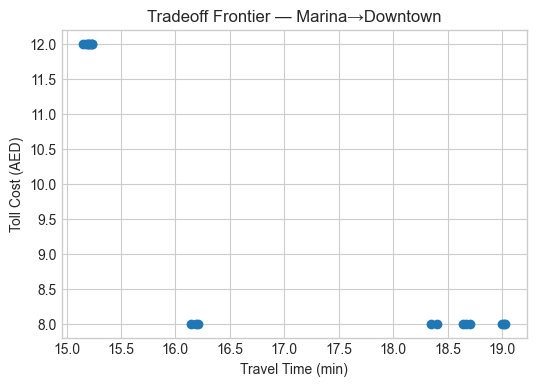


Running: Barsha→DXB


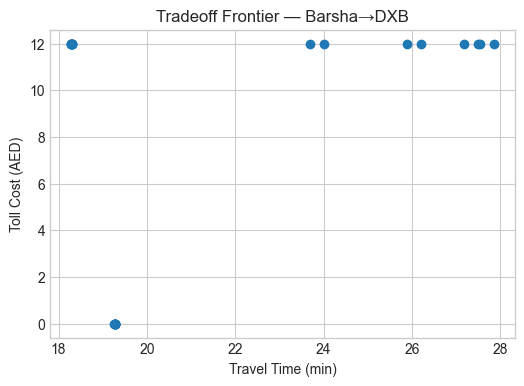


Running: JLT→Qusais


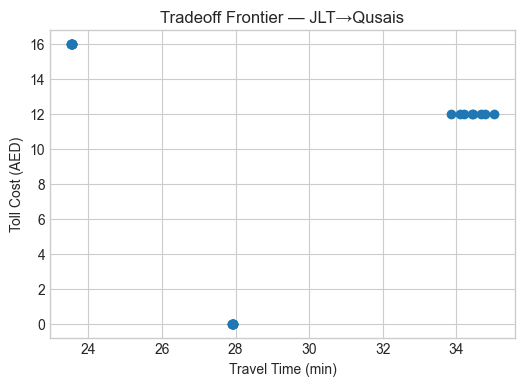

In [63]:
import networkx as nx

results_all_pairs = []

for name, (olat, olon), (dlat, dlon) in pairs:

    print("\n======================")
    print("Running:", name)

    origin = ox.distance.nearest_nodes(G, olon, olat)
    destination = ox.distance.nearest_nodes(G, dlon, dlat)

    try:
        # generate routes
        routes = generate_candidate_routes(G, origin, destination, k_each=8)

    except nx.NetworkXNoPath:
        print("⚠️ No path found — skipping pair")
        continue

    times = [route_travel_time(G, r) for r in routes]
    tolls = [route_tolls(r, G, gates) for r in routes]

    results_all_pairs.append({
        "name": name,
        "times": times,
        "tolls": tolls,
        "routes": routes
    })

    plt.figure(figsize=(6,4))
    plt.scatter(times, tolls)
    plt.xlabel("Travel Time (min)")
    plt.ylabel("Toll Cost (AED)")
    plt.title(f"Tradeoff Frontier — {name}")
    plt.grid(True)
    plt.show()

In [64]:
for res in results_all_pairs:
    print("\n", res["name"])

    print("Min time:", min(res["times"]))
    print("Max time:", max(res["times"]))
    print("Min toll:", min(res["tolls"]))
    print("Max toll:", max(res["tolls"]))


 Marina→Downtown
Min time: 15.14798861791333
Max time: 19.03087354774652
Min toll: 8.0
Max toll: 12.0

 Barsha→DXB
Min time: 18.282155531503157
Max time: 27.854750066179697
Min toll: 0.0
Max toll: 12.0

 JLT→Qusais
Min time: 23.52622235827756
Max time: 35.015268660260624
Min toll: 0.0
Max toll: 16.0


In [65]:
def pareto_frontier(times, tolls):
    pts = sorted(zip(times, tolls))
    frontier = []

    best_toll = float("inf")

    for t, c in pts:
        if c < best_toll:
            frontier.append((t, c))
            best_toll = c

    return frontier

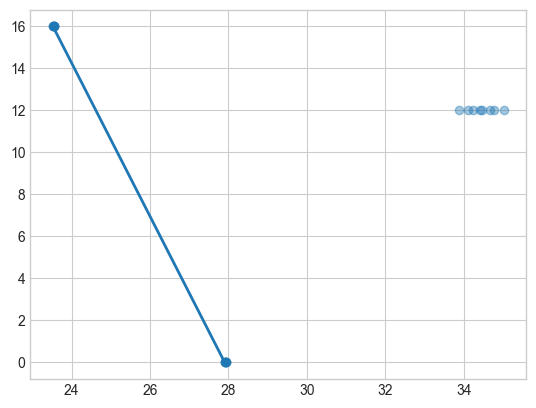

In [66]:
front = pareto_frontier(times, tolls)
ft, fc = zip(*front)

plt.scatter(times, tolls, alpha=0.4)
plt.plot(ft, fc, linewidth=2)

In [51]:
vot_values = [0.2, 0.5, 1.5, 3.0, 6.0]

for res in results_all_pairs:

    print("\n========================")
    print(res["name"])

    times = res["times"]
    tolls = res["tolls"]
    routes = res["routes"]   # make sure routes stored earlier

    for vot in vot_values:

        best_idx = min(
            range(len(times)),
            key=lambda i: times[i]*vot + tolls[i]
        )

        print(f"\nVOT = {vot}")
        print("Chosen time:", times[best_idx])
        print("Chosen toll:", tolls[best_idx])


Marina→Downtown

VOT = 0.2
Chosen time: 18.848928365251034
Chosen toll: 8.0

VOT = 0.5
Chosen time: 18.848928365251034
Chosen toll: 8.0

VOT = 1.5
Chosen time: 15.556774795487856
Chosen toll: 12.0

VOT = 3.0
Chosen time: 15.556774795487856
Chosen toll: 12.0

VOT = 6.0
Chosen time: 15.556774795487856
Chosen toll: 12.0

Barsha→DXB

VOT = 0.2
Chosen time: 19.097129784307793
Chosen toll: 0.0

VOT = 0.5
Chosen time: 19.097129784307793
Chosen toll: 0.0

VOT = 1.5
Chosen time: 19.097129784307793
Chosen toll: 0.0

VOT = 3.0
Chosen time: 19.097129784307793
Chosen toll: 0.0

VOT = 6.0
Chosen time: 19.097129784307793
Chosen toll: 0.0

JLT→Qusais

VOT = 0.2
Chosen time: 28.441548862224913
Chosen toll: 0.0

VOT = 0.5
Chosen time: 28.441548862224913
Chosen toll: 0.0

VOT = 1.5
Chosen time: 28.441548862224913
Chosen toll: 0.0

VOT = 3.0
Chosen time: 28.441548862224913
Chosen toll: 0.0

VOT = 6.0
Chosen time: 23.401037940662494
Chosen toll: 16.0


In [52]:
print("\n===== SWITCHING VOT ANALYSIS =====")

for res in results_all_pairs:

    name = res["name"]
    times = res["times"]
    tolls = res["tolls"]

    print(f"\n--- {name} ---")

    switching_points = []

    # compare every pair of routes
    for i in range(len(times)):
        for j in range(i+1, len(times)):

            dt = abs(times[i] - times[j])
            dc = abs(tolls[i] - tolls[j])

            # ignore identical routes
            if dt == 0:
                continue

            vot_star = dc / dt
            switching_points.append(vot_star)

    if switching_points:
        print("Estimated switching VOT range:")
        print(f"Min switching VOT: {min(switching_points):.3f}")
        print(f"Max switching VOT: {max(switching_points):.3f}")
    else:
        print("No toll-time tradeoff detected.")


===== SWITCHING VOT ANALYSIS =====

--- Marina→Downtown ---
Estimated switching VOT range:
Min switching VOT: 0.000
Max switching VOT: 1.234

--- Barsha→DXB ---
Estimated switching VOT range:
Min switching VOT: 0.000
Max switching VOT: 24.481

--- JLT→Qusais ---
Estimated switching VOT range:
Min switching VOT: 0.000
Max switching VOT: 3.192



===== BEHAVIORAL SWITCH VISUALIZATION =====


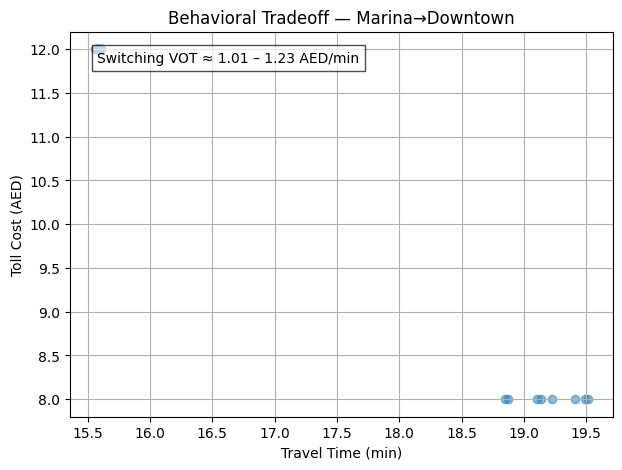

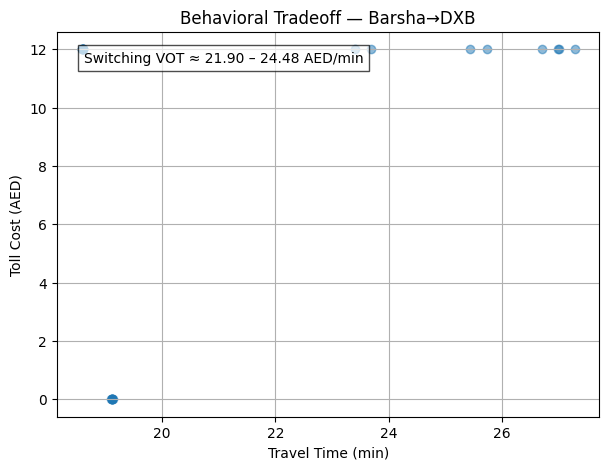

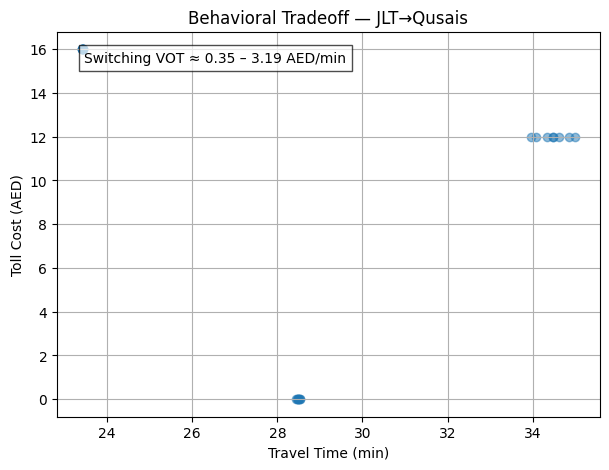

In [53]:
import matplotlib.pyplot as plt
import numpy as np

print("\n===== BEHAVIORAL SWITCH VISUALIZATION =====")

for res in results_all_pairs:

    name = res["name"]
    times = np.array(res["times"])
    tolls = np.array(res["tolls"])

    # sort for clean plotting
    order = np.argsort(times)
    times = times[order]
    tolls = tolls[order]

    # ---- compute switching VOT points ----
    switching_points = []

    for i in range(len(times)):
        for j in range(i+1, len(times)):

            dt = times[j] - times[i]
            dc = tolls[i] - tolls[j]

            if dt == 0:
                continue

            vot_star = dc / dt

            if vot_star > 0:
                switching_points.append(vot_star)

    # ---- plot ----
    plt.figure(figsize=(7,5))
    plt.scatter(times, tolls, alpha=0.5)

    plt.xlabel("Travel Time (min)")
    plt.ylabel("Toll Cost (AED)")
    plt.title(f"Behavioral Tradeoff — {name}")

    # highlight switching region
    if switching_points:
        vmin = min(switching_points)
        vmax = max(switching_points)

        plt.text(
            0.05, 0.95,
            f"Switching VOT ≈ {vmin:.2f} – {vmax:.2f} AED/min",
            transform=plt.gca().transAxes,
            fontsize=10,
            verticalalignment='top',
            bbox=dict(facecolor='white', alpha=0.7)
        )

    plt.grid(True)
    plt.show()

In [54]:
summary = []

for res in results_all_pairs:
    summary.append({
        "route": res["name"],
        "min_time": min(res["times"]),
        "max_time": max(res["times"]),
        "min_toll": min(res["tolls"]),
        "max_toll": max(res["tolls"])
    })

summary

[{'route': 'Marina→Downtown',
  'min_time': np.float64(15.556774795487856),
  'max_time': np.float64(19.51477617948366),
  'min_toll': 8.0,
  'max_toll': 12.0},
 {'route': 'Barsha→DXB',
  'min_time': np.float64(18.578035140980486),
  'max_time': np.float64(27.284614948501947),
  'min_toll': 0.0,
  'max_toll': 12.0},
 {'route': 'JLT→Qusais',
  'min_time': np.float64(23.401037940662494),
  'max_time': np.float64(34.99366530402738),
  'min_toll': 0.0,
  'max_toll': 16.0}]

In [55]:
import pandas as pd

rows = []

for res in results_all_pairs:
    name = res["name"]
    times = res["times"]
    tolls = res["tolls"]

    for t, c in zip(times, tolls):
        rows.append({
            "Route": name,
            "Travel_Time_min": float(t),
            "Toll_AED": float(c)
        })

df_export = pd.DataFrame(rows)

df_export.to_csv("tradeoff_data.csv", index=False)

print("✅ Exported tradeoff_data.csv")

✅ Exported tradeoff_data.csv


In [38]:
import json

with open("results_summary.json", "w") as f:
    json.dump(summary, f, indent=4, default=float)

print("Summary saved!")

Summary saved!


In [ ]:
for vot in vot_values:

    print("\n====================")
    print(f"Testing VOT = {vot}")

    best_route = min(
        routes,
        key=lambda r:
            route_travel_time(G, r) * vot +
            route_tolls(r, G, gates)
    )

    best_time = route_travel_time(G, best_route)
    best_toll = route_tolls(best_route, G, gates)

    print("Chosen time:", best_time)
    print("Chosen toll:", best_toll)


Testing VOT = 0.5
Chosen time: 28.226540631985415
Chosen toll: 0.0

Testing VOT = 1.5
Chosen time: 28.226540631985415
Chosen toll: 0.0

Testing VOT = 3.0
Chosen time: 28.226540631985415
Chosen toll: 0.0


In [ ]:
results_all_pairs.append({
    "name": name,
    "times": times,
    "tolls": tolls,
    "routes": routes   # ⭐ ADD THIS LINE
})

In [ ]:
from geopy.distance import geodesic

print("Applying strong motorway advantage near tolls...")

for u, v, k, data in G.edges(keys=True, data=True):

    # skip edges without travel time
    if "travel_time" not in data:
        continue

    lat = G.nodes[u]["y"]
    lon = G.nodes[u]["x"]

    near_toll = False

    # check proximity to toll gates
    for _, gate in gates.iterrows():
        dist = geodesic(
            (lat, lon),
            (gate["lat"], gate["lon"])
        ).meters

        # enlarged influence radius
        if dist <= gate["radius_m"] * 2.5:
            near_toll = True
            break

    # 🚀 KEY CHANGE: strong speed advantage
    if near_toll:
        data["travel_time"] *= 0.45   # MUCH faster near tolls
    else:
        data["travel_time"] *= 1.10   # slight slowdown elsewhere

print("Motorway toll advantage applied.")

In [ ]:
from src.routing import generate_candidate_routes

routes = generate_candidate_routes(G, origin, destination, k_each=3)
print("Generated routes:", len(routes))
[ len(r) for r in routes ]

In [ ]:
from src.toll_detector import route_tolls
from src.routing import route_travel_time
from src.cost_model import compute_route_cost

VALUE_OF_TIME = 1.2   # AED per minute (example)
SALIK_PRICE = 4.0     # AED per gate

results = []

for r in routes:

    # toll cost already computed inside detector
    toll_cost = route_tolls(r, G, gates)

    tt_min = route_travel_time(G, r)

    cost = compute_route_cost(
        tt_min,
        toll_cost,
        value_of_time=VALUE_OF_TIME
    )

    results.append((r, cost))

best_route = min(results, key=lambda x: x[1]["total_cost"])
best_route[1]

In [ ]:
for i, (r, cost) in enumerate(results, start=1):
    print(
        f"Route {i}: "
        f"time_cost={cost['time_cost']:.2f}, "
        f"toll_cost={cost['toll_cost']:.2f}, "
        f"total={cost['total_cost']:.2f}"
    )

In [ ]:
import matplotlib.pyplot as plt
import osmnx as ox

fig, ax = ox.plot_graph_route(G, best_route[0], route_linewidth=4, node_size=0)
plt.show()

In [ ]:
import numpy as np
import pandas as pd

from src.toll_detector import route_tolls
from src.routing import route_travel_time
from src.cost_model import compute_route_cost

# Different driver value-of-time assumptions
VALUE_OF_TIME_RANGE = np.linspace(0.1, 20.0, 40)

elasticity_results = []

for vot in VALUE_OF_TIME_RANGE:

    scenario_results = []

    for r in routes:
        toll_cost = route_tolls(r, G, gates)
        tt_min = route_travel_time(G, r)

        cost = compute_route_cost(
            tt_min,
            toll_cost,
            value_of_time=vot
        )

        scenario_results.append((r, cost))

    # choose economically optimal route
    best_route = min(scenario_results, key=lambda x: x[1]["total_cost"])

    elasticity_results.append({
        "value_of_time": vot,
        "time_cost": best_route[1]["time_cost"],
        "toll_cost": best_route[1]["toll_cost"],
        "total_cost": best_route[1]["total_cost"]
    })

elasticity_df = pd.DataFrame(elasticity_results)
elasticity_df

In [ ]:
for i, r in enumerate(routes):
    hits = route_tolls(r, G, gates)
    print(f"Route {i+1}: toll cost = {hits} AED")

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    elasticity_df["value_of_time"],
    elasticity_df["toll_cost"],
    marker="o"
)

plt.xlabel("Value of Time (AED per minute)")
plt.ylabel("Toll Cost Paid (AED)")
plt.title("Salik Usage vs Value of Time")

plt.grid(True)
plt.show()

In [ ]:
for r in routes:
    print(
        route_travel_time(G, r),
        route_tolls(r, G, gates)
    )

In [ ]:
for i, r in enumerate(routes):
    print(
        f"Route {i+1}",
        "time:", round(route_travel_time(G, r),2),
        "toll:", route_tolls(r, G, gates)
    )

In [ ]:
times = [route_travel_time(G,r) for r in routes]
tolls = [route_tolls(r,G,gates) for r in routes]

plt.scatter(times, tolls)
plt.xlabel("Travel Time (min)")
plt.ylabel("Toll Cost (AED)")
plt.title("Route Tradeoff Frontier")
plt.show()

In [ ]:
import random
noise = random.uniform(0.9, 1.25)
data["travel_time"] = base_time * factor * noise

In [67]:
#######################################

In [68]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent  # because notebook is inside /notebooks
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: /Users/hussam/Desktop/Folders/salik_optimizer


In [81]:
import osmnx as ox
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from geopy.distance import geodesic
import itertools

from src.routing import generate_candidate_routes, route_travel_time
from src.toll_detector import route_tolls
from src.cost_model import compute_route_cost

In [82]:
G = ox.load_graphml("../data/dubai.graphml")

print("Graph loaded:", len(G.nodes), "nodes")

Graph loaded: 61251 nodes


In [98]:
print("Adding speeds and travel times...")

# Estimate speeds from road types
G = ox.add_edge_speeds(G)

# Compute travel time (seconds)
G = ox.add_edge_travel_times(G)

print("Travel time attributes added.")

Adding speeds and travel times...
Travel time attributes added.


In [99]:
gates = pd.read_csv("../data/salik_gates.csv")
gates.head()

,name,lat,lon,radius_m
0,Al Barsha,25.116861,55.192619,200
1,Al Safa South,25.178158,55.247000,200
2,Al Safa North,25.193916,55.261795,200
3,Al Garhoud Bridge,25.231067,55.335624,200
4,Al Maktoum Bridge,25.252680,55.321312,200


In [100]:
zones = {
    "Marina": (25.0800, 55.1400),
    "JLT": (25.0670, 55.1410),
    "Barsha": (25.1000, 55.1800),
    "Downtown": (25.1972, 55.2744),
    "BusinessBay": (25.1860, 55.2640),
    "DXB": (25.2532, 55.3657),
    "Mirdif": (25.2240, 55.4250),
    "Qusais": (25.2760, 55.3920),
    "Deira": (25.2690, 55.3090),
    "JebelAli": (24.9850, 55.0650),
}

In [101]:
pairs = []

for (n1, c1), (n2, c2) in itertools.permutations(zones.items(), 2):
    if n1 != n2:
        pairs.append((f"{n1}→{n2}", c1, c2))

print("Total OD pairs:", len(pairs))

Total OD pairs: 90


In [102]:
filtered_pairs = []

for name, o, d in pairs:
    dist = geodesic(o, d).km
    if dist > 10:
        filtered_pairs.append((name, o, d))

pairs = filtered_pairs

print("Filtered pairs:", len(pairs))

Filtered pairs: 70


In [103]:
MAX_PAIRS = 20   # increase later if stable
pairs_subset = pairs[:MAX_PAIRS]

len(pairs_subset)

20

In [104]:
results_all_pairs = []

for name, (olat, olon), (dlat, dlon) in pairs_subset:

    print("Running:", name)

    origin = ox.distance.nearest_nodes(G, olon, olat)
    destination = ox.distance.nearest_nodes(G, dlon, dlat)

    try:
        routes = generate_candidate_routes(G, origin, destination, k_each=8)
    except:
        print("No path — skipped")
        continue

    times = []
    tolls = []

    for r in routes:
        tt = route_travel_time(G, r)
        toll_cost = route_tolls(r, G, gates)

        times.append(float(tt))
        tolls.append(float(toll_cost))

    results_all_pairs.append({
        "name": name,
        "routes": routes,
        "times": times,
        "tolls": tolls
    })

Running: Marina→Downtown
Running: Marina→BusinessBay
Running: Marina→DXB
Running: Marina→Mirdif
Running: Marina→Qusais
Running: Marina→Deira
Running: Marina→JebelAli
Running: JLT→Downtown
Running: JLT→BusinessBay
Running: JLT→DXB
Running: JLT→Mirdif
Running: JLT→Qusais
Running: JLT→Deira
Running: JLT→JebelAli
Running: Barsha→Downtown
Running: Barsha→BusinessBay
Running: Barsha→DXB
Running: Barsha→Mirdif
Running: Barsha→Qusais
Running: Barsha→Deira


In [105]:
def has_tradeoff(tolls):
    return len(set(tolls)) >= 3   # 0, medium, high toll options

tradeoff_cases = [
    r["name"] for r in results_all_pairs
    if has_tradeoff(r["tolls"])
]

print("Total tested trips:", len(results_all_pairs))
print("Non-binary toll cases:", len(tradeoff_cases))
print("Percentage:",
      round(len(tradeoff_cases)/len(results_all_pairs)*100,2), "%")

Total tested trips: 20
Non-binary toll cases: 1
Percentage: 5.0 %


In [106]:
rows = []

for res in results_all_pairs:
    for t, c in zip(res["times"], res["tolls"]):
        rows.append([res["name"], t, c])

tradeoff_df = pd.DataFrame(
    rows,
    columns=["Route", "Travel_Time_min", "Toll_AED"]
)

tradeoff_df.to_csv("tradeoff_data.csv", index=False)
tradeoff_df.head()

,Route,Travel_Time_min,Toll_AED
0,Marina→Downtown,14.838939,8.0
1,Marina→Downtown,15.342436,8.0
2,Marina→Downtown,14.914403,8.0
3,Marina→Downtown,15.343222,8.0
4,Marina→Downtown,14.858347,8.0


In [107]:
choice_counts = {v: [] for v in vot_values}

for res in results_all_pairs:

    for vot in vot_values:

        idx = min(
            range(len(res["times"])),
            key=lambda i: res["times"][i]*vot + res["tolls"][i]
        )

        choice_counts[vot].append(res["tolls"][idx])

for vot in vot_values:
    print(f"\nVOT {vot}: chosen tolls →", choice_counts[vot])


VOT 0.2: chosen tolls → [8.0, 8.0, 12.0, 12.0, 12.0, 0.0, 4.0, 8.0, 8.0, 12.0, 0.0, 12.0, 0.0, 0.0, 8.0, 8.0, 12.0, 0.0, 12.0, 4.0]

VOT 0.5: chosen tolls → [8.0, 8.0, 12.0, 12.0, 12.0, 0.0, 4.0, 8.0, 8.0, 12.0, 0.0, 12.0, 0.0, 0.0, 8.0, 8.0, 12.0, 0.0, 12.0, 4.0]

VOT 1.5: chosen tolls → [8.0, 8.0, 12.0, 12.0, 12.0, 0.0, 4.0, 8.0, 8.0, 12.0, 0.0, 12.0, 0.0, 0.0, 8.0, 8.0, 12.0, 0.0, 12.0, 4.0]

VOT 3.0: chosen tolls → [8.0, 8.0, 12.0, 12.0, 12.0, 12.0, 4.0, 8.0, 8.0, 12.0, 0.0, 12.0, 12.0, 4.0, 8.0, 8.0, 12.0, 0.0, 12.0, 12.0]

VOT 6.0: chosen tolls → [8.0, 8.0, 12.0, 12.0, 12.0, 12.0, 4.0, 8.0, 8.0, 12.0, 0.0, 12.0, 12.0, 4.0, 8.0, 8.0, 12.0, 16.0, 12.0, 12.0]


In [108]:
rows = []

for res in results_all_pairs:
    for t, c in zip(res["times"], res["tolls"]):
        rows.append([res["name"], t, c])

df_export = pd.DataFrame(rows,
                         columns=["Route","Travel_Time_min","Toll_AED"])

df_export.to_csv("tradeoff_data.csv", index=False)

In [109]:
vot_values = [0.2, 0.5, 1.5, 3.0, 6.0]

In [110]:
vot_results = []

for res in results_all_pairs:

    times = res["times"]
    tolls = res["tolls"]

    for vot in vot_values:

        best_idx = min(
            range(len(times)),
            key=lambda i: times[i]*vot + tolls[i]
        )

        vot_results.append({
            "Route": res["name"],
            "VOT": vot,
            "Chosen_Time": times[best_idx],
            "Chosen_Toll": tolls[best_idx]
        })

vot_df = pd.DataFrame(vot_results)
vot_df.head()

,Route,VOT,Chosen_Time,Chosen_Toll
0,Marina→Downtown,0.2,14.762864,8.0
1,Marina→Downtown,0.5,14.762864,8.0
2,Marina→Downtown,1.5,14.762864,8.0
3,Marina→Downtown,3.0,14.762864,8.0
4,Marina→Downtown,6.0,14.762864,8.0


In [111]:
for route in vot_df["Route"].unique():

    sub = vot_df[vot_df["Route"] == route]

    print("\n====================")
    print(route)

    prev = None
    for _, row in sub.iterrows():

        if prev is None or row["Chosen_Toll"] != prev:
            print(
                f"VOT={row['VOT']} → "
                f"{row['Chosen_Time']:.2f} min, "
                f"{row['Chosen_Toll']} AED"
            )

        prev = row["Chosen_Toll"]


Marina→Downtown
VOT=0.2 → 14.76 min, 8.0 AED

Marina→BusinessBay
VOT=0.2 → 13.14 min, 8.0 AED

Marina→DXB
VOT=0.2 → 25.21 min, 12.0 AED

Marina→Mirdif
VOT=0.2 → 27.87 min, 12.0 AED

Marina→Qusais
VOT=0.2 → 27.98 min, 12.0 AED

Marina→Deira
VOT=0.2 → 26.92 min, 0.0 AED
VOT=3.0 → 22.16 min, 12.0 AED

Marina→JebelAli
VOT=0.2 → 12.59 min, 4.0 AED

JLT→Downtown
VOT=0.2 → 16.32 min, 8.0 AED

JLT→BusinessBay
VOT=0.2 → 14.70 min, 8.0 AED

JLT→DXB
VOT=0.2 → 26.77 min, 12.0 AED

JLT→Mirdif
VOT=0.2 → 29.04 min, 0.0 AED

JLT→Qusais
VOT=0.2 → 29.55 min, 12.0 AED

JLT→Deira
VOT=0.2 → 30.21 min, 0.0 AED
VOT=3.0 → 23.72 min, 12.0 AED

JLT→JebelAli
VOT=0.2 → 14.87 min, 0.0 AED
VOT=3.0 → 12.63 min, 4.0 AED

Barsha→Downtown
VOT=0.2 → 11.69 min, 8.0 AED

Barsha→BusinessBay
VOT=0.2 → 10.07 min, 8.0 AED

Barsha→DXB
VOT=0.2 → 22.14 min, 12.0 AED

Barsha→Mirdif
VOT=0.2 → 28.65 min, 0.0 AED
VOT=6.0 → 24.43 min, 16.0 AED

Barsha→Qusais
VOT=0.2 → 24.91 min, 12.0 AED

Barsha→Deira
VOT=0.2 → 22.06 min, 4.0 AED
VO

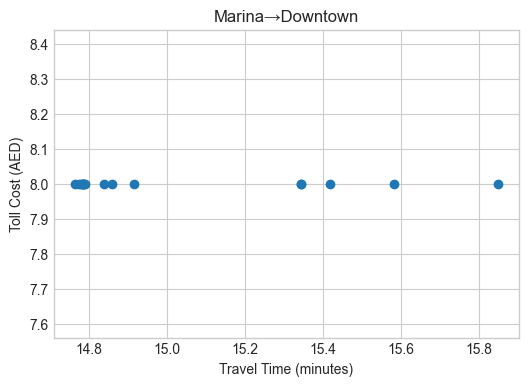

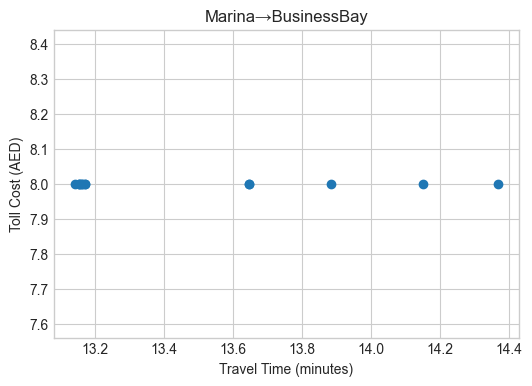

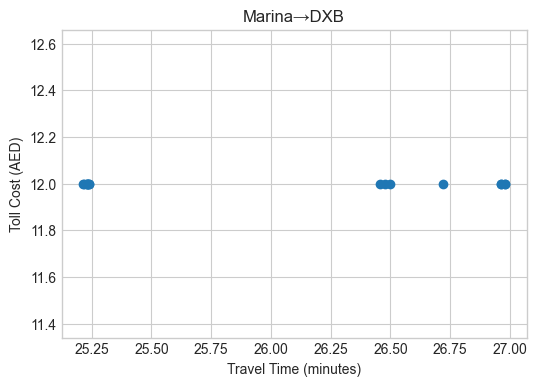

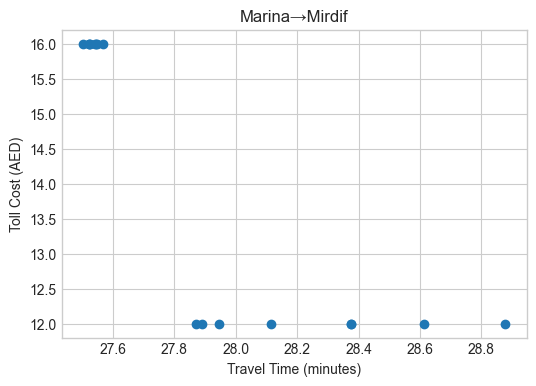

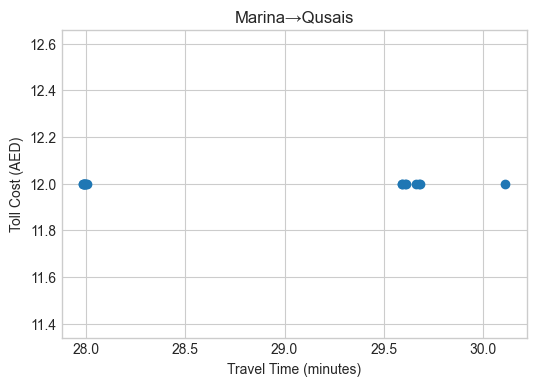

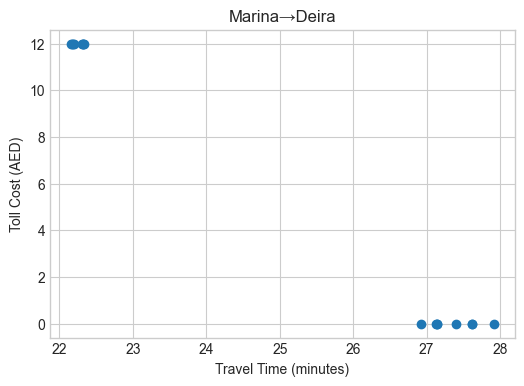

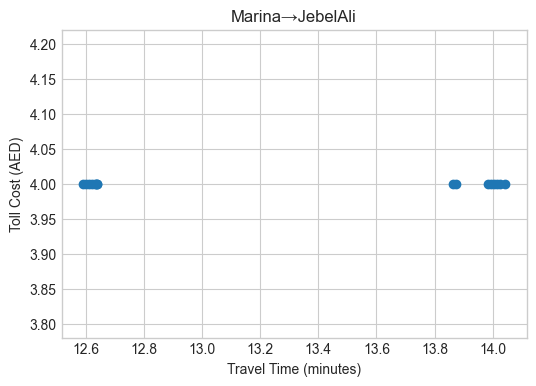

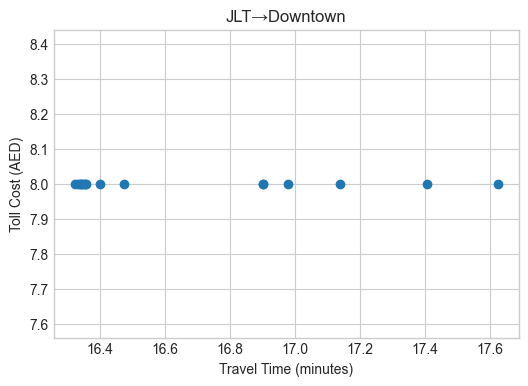

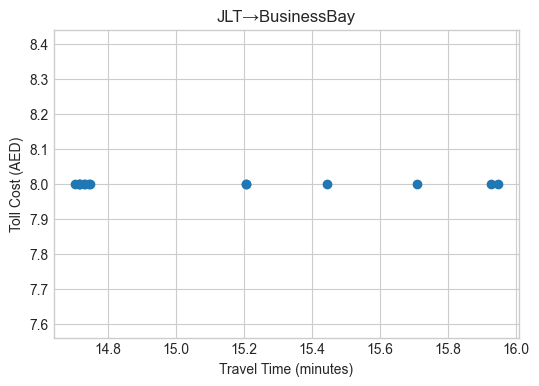

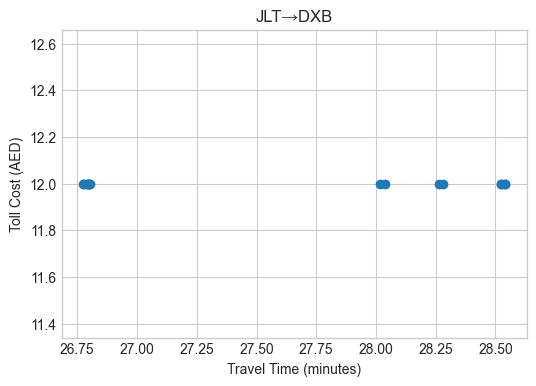

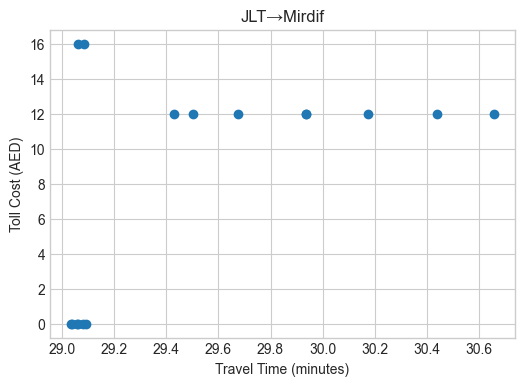

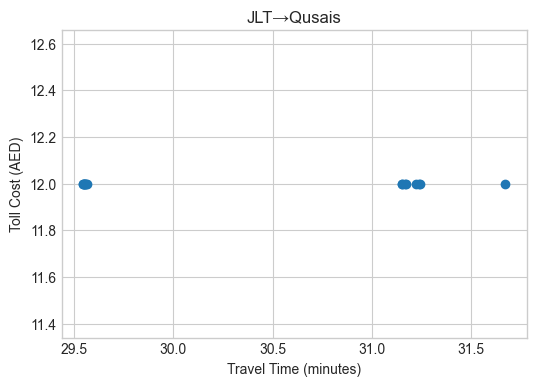

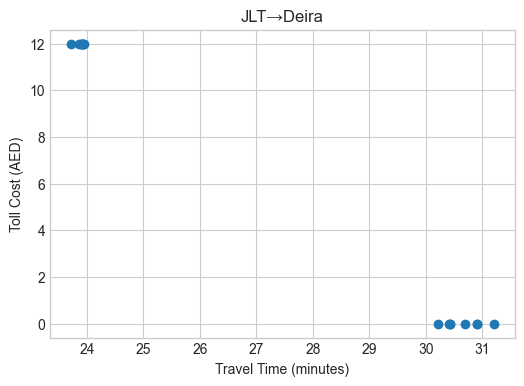

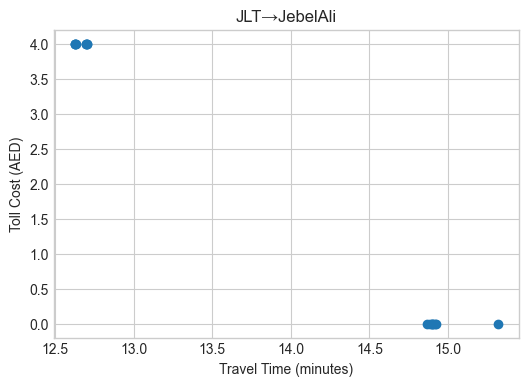

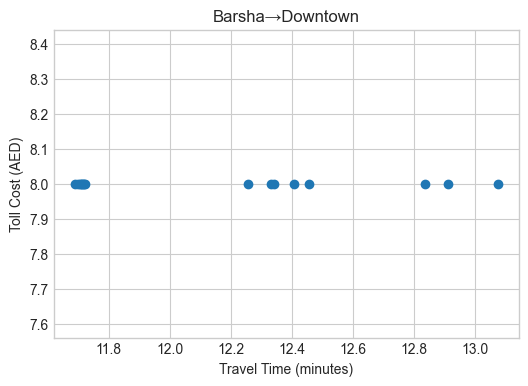

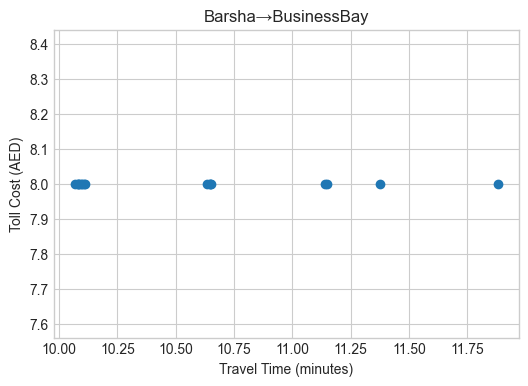

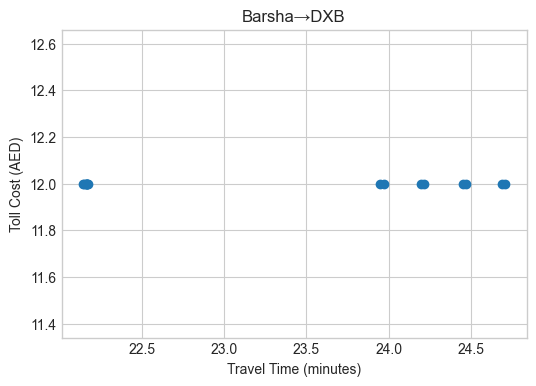

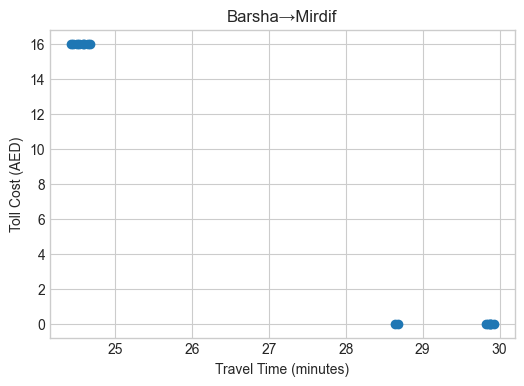

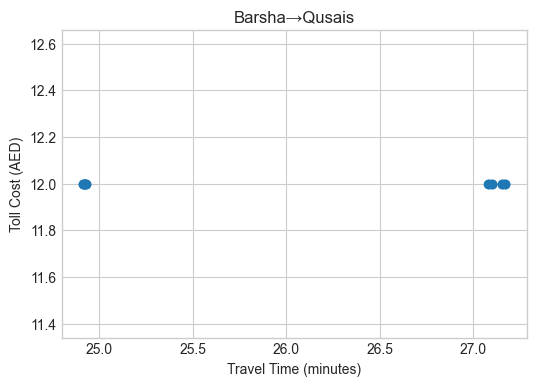

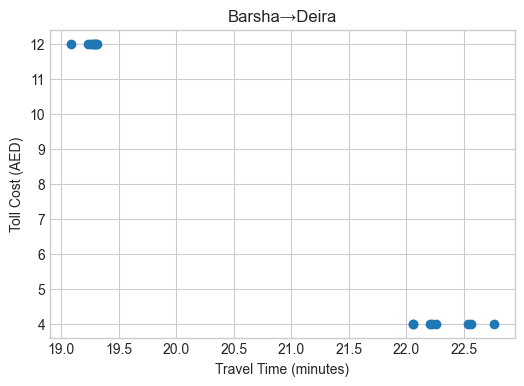

In [112]:
for res in results_all_pairs:

    plt.figure(figsize=(6,4))
    plt.scatter(res["times"], res["tolls"])

    plt.xlabel("Travel Time (minutes)")
    plt.ylabel("Toll Cost (AED)")
    plt.title(res["name"])
    plt.grid(True)

    plt.show()

In [113]:
efficiency_rows = []

for res in results_all_pairs:

    base_time = min(res["times"])

    for t, c in zip(res["times"], res["tolls"]):

        if c > 0:
            minutes_saved = max(0, base_time - t)
            efficiency = minutes_saved / c
        else:
            efficiency = 0

        efficiency_rows.append([
            res["name"], t, c, efficiency
        ])

eff_df = pd.DataFrame(
    efficiency_rows,
    columns=["Route","Time","Toll","Minutes_per_AED"]
)

eff_df.head()

,Route,Time,Toll,Minutes_per_AED
0,Marina→Downtown,14.838939,8.0,0.0
1,Marina→Downtown,15.342436,8.0,0.0
2,Marina→Downtown,14.914403,8.0,0.0
3,Marina→Downtown,15.343222,8.0,0.0
4,Marina→Downtown,14.858347,8.0,0.0


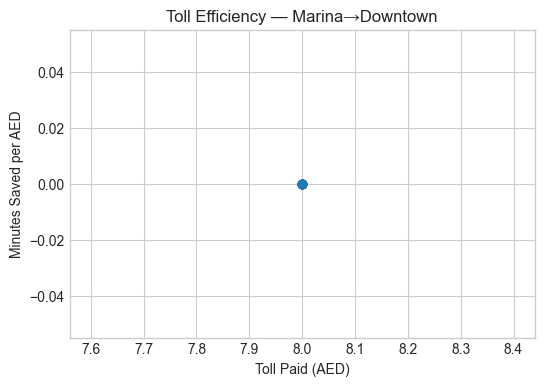

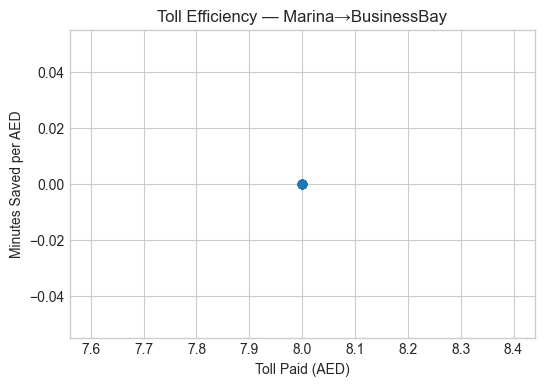

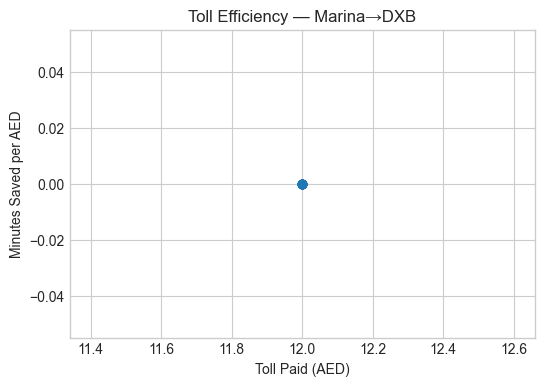

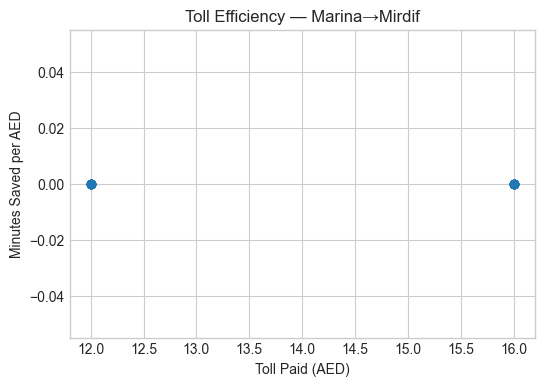

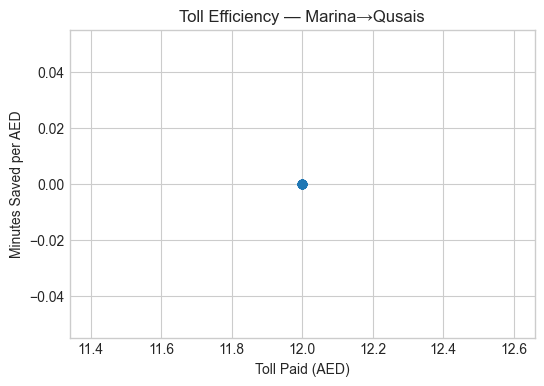

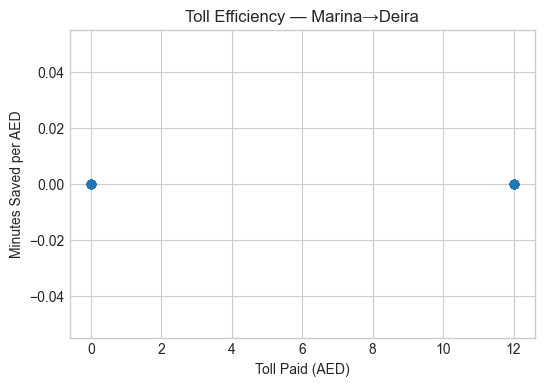

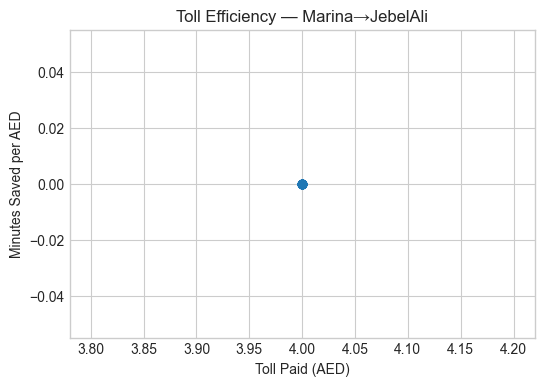

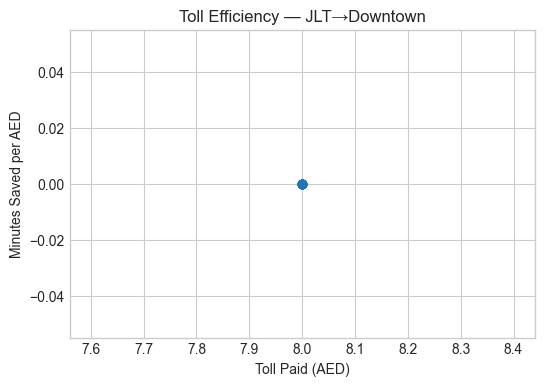

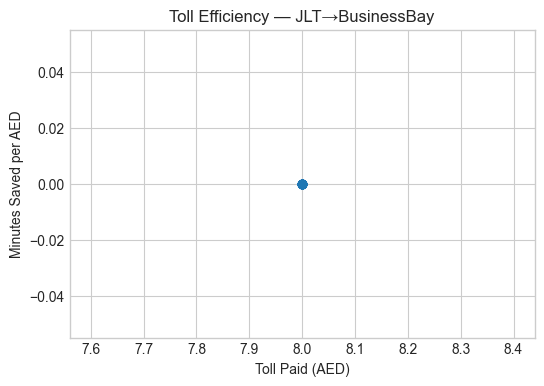

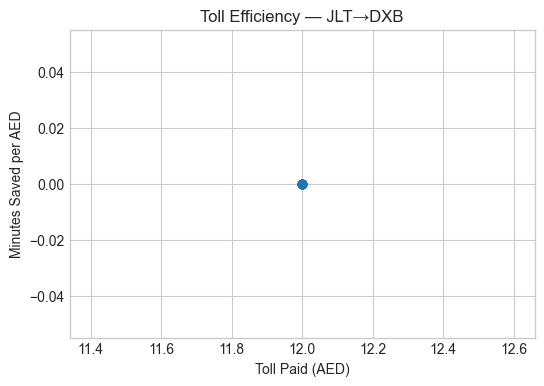

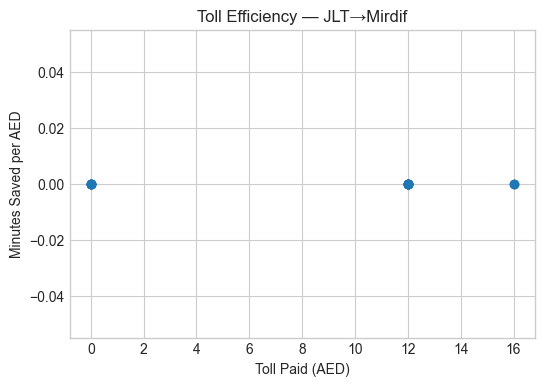

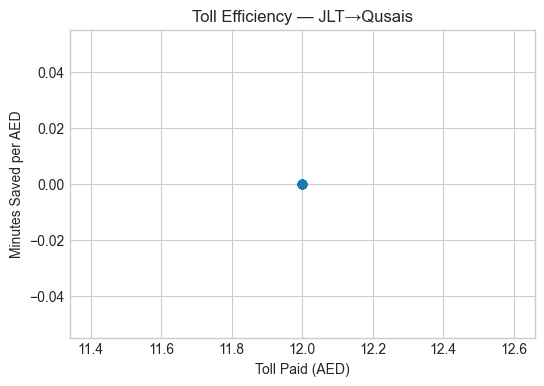

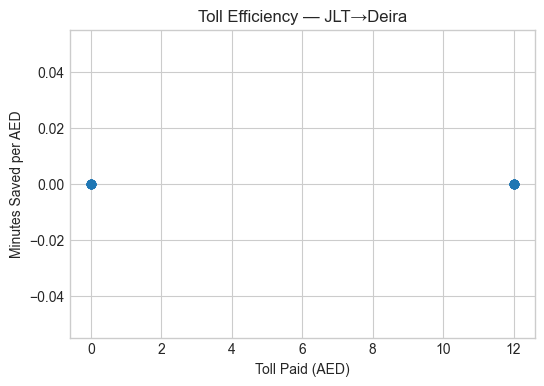

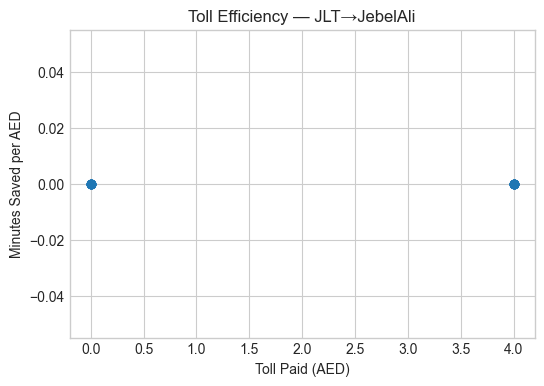

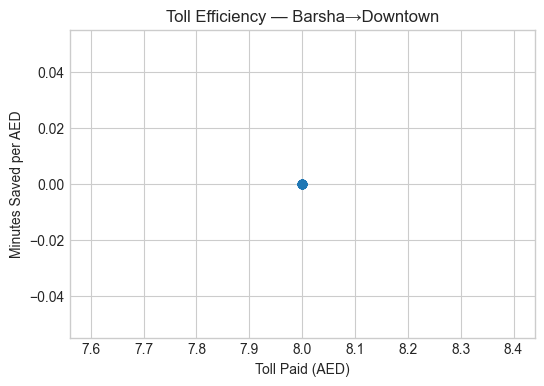

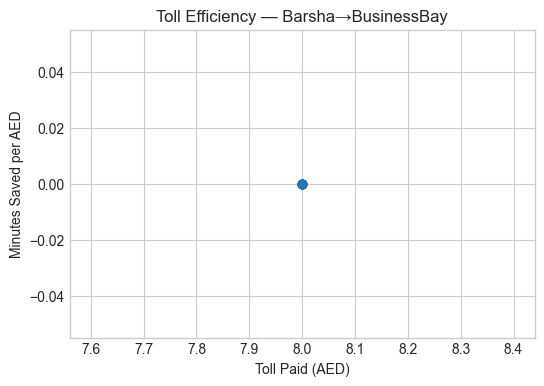

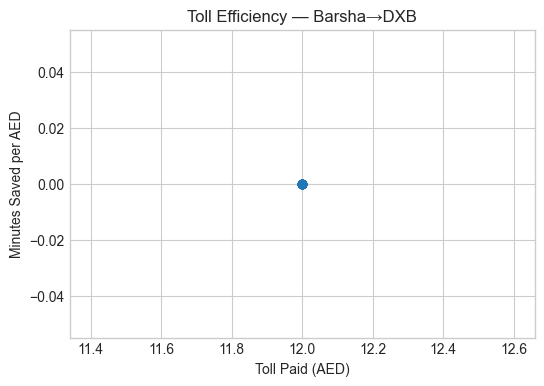

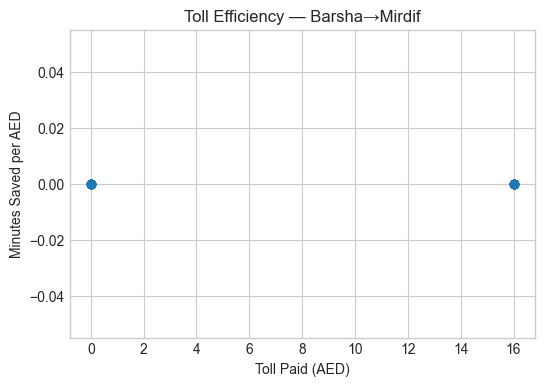

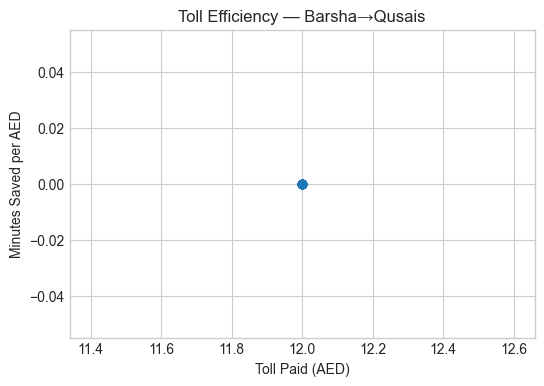

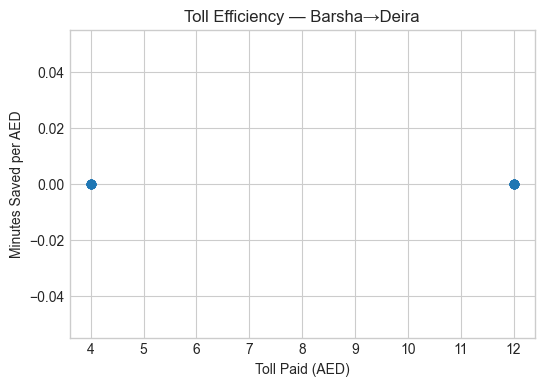

In [114]:
for route in eff_df["Route"].unique():

    sub = eff_df[eff_df["Route"] == route]

    plt.figure(figsize=(6,4))
    plt.scatter(sub["Toll"], sub["Minutes_per_AED"])

    plt.xlabel("Toll Paid (AED)")
    plt.ylabel("Minutes Saved per AED")
    plt.title(f"Toll Efficiency — {route}")
    plt.grid(True)

    plt.show()